# Random Forest Regression

In this notebook we train a Random Forest Regressor and compare its performance with Linear Regression and Decision Tree models.

In [2]:
from pathlib import Path
import sys

import pandas as pd

from sklearn.ensemble import RandomForestRegressor

In [3]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [4]:
from src.data_loader import load_data
from src.preprocessing import clean_data
from src.feature_engineering import engineer_features
from src.encoding import encode_features
from src.split_data import split_data
from src.evaluation import evaluate_model

## Load Dataset

In [5]:
df = load_data()

df = clean_data(df)

df = engineer_features(df)

df = encode_features(df)

X_train, X_test, y_train, y_test = split_data(df)

In [6]:
print(X_train.shape)
print(X_test.shape)

(1020, 71)
(255, 71)


## Train Random Forest

In [7]:
forest = RandomForestRegressor(
    random_state=42
)

In [8]:
forest.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [9]:
y_pred = forest.predict(
    X_test
)

In [10]:
comparison = pd.DataFrame(
    {
        "Actual Price": y_test,
        "Predicted Price": y_pred,
    }
)

comparison.head(10)

,Actual Price,Predicted Price
1179,650.00,659.987300
342,716.00,762.102700
649,1584.00,1654.923300
772,1020.00,839.549033
803,1749.00,1643.987900
358,557.37,627.171200
44,999.00,1031.300000
231,330.00,322.713575
618,2267.86,1873.572167
43,682.00,757.958200


## Model Evaluation

In [11]:
metrics = evaluate_model(
    y_test,
    y_pred
)

metrics

{'MAE': 179.93031926672893, 'RMSE': 268.421052040611, 'R2': 0.8548374774253108}

In [12]:
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

MAE: 179.9303
RMSE: 268.4211
R2: 0.8548


## Training Score vs Test Score

In [13]:
train_score = forest.score(
    X_train,
    y_train
)

test_score = forest.score(
    X_test,
    y_test
)

print(f"Train R² : {train_score:.4f}")

print(f"Test  R² : {test_score:.4f}")

Train R² : 0.9728
Test  R² : 0.8548


In [14]:
import matplotlib.pyplot as plt

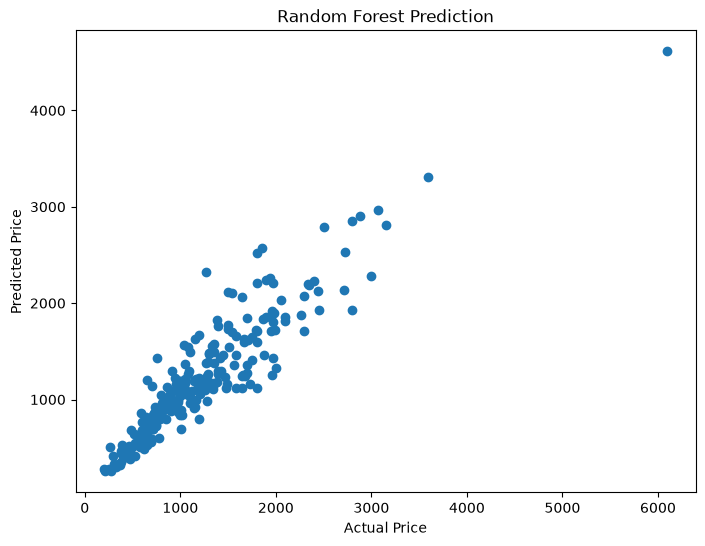

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Random Forest Prediction")

plt.show()

In [16]:
residuals = y_test - y_pred

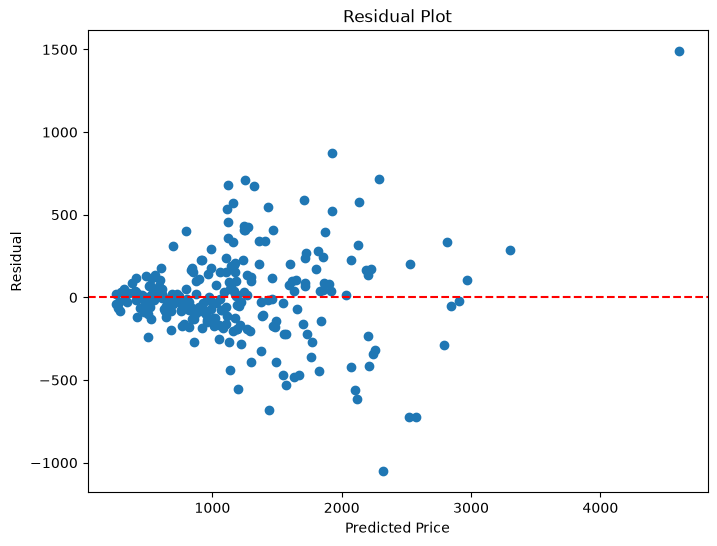

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

## Feature Importance

In [18]:
importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": forest.feature_importances_,
    }
)

In [19]:
importance = importance.sort_values(
    by="Importance",
    ascending=False,
)

In [20]:
importance.head(20)

,Feature,Importance
2,ram,0.518016
3,weight,0.090077
35,type_name_Notebook,0.060941
1,cpu_frequency,0.042704
59,cpu_family_Core i7,0.040626
4,ssd,0.032738
12,ppi,0.028521
68,gpu_family_Quadro,0.025712
0,inches,0.018909
58,cpu_family_Core i5,0.017963


In [21]:
import matplotlib.pyplot as plt

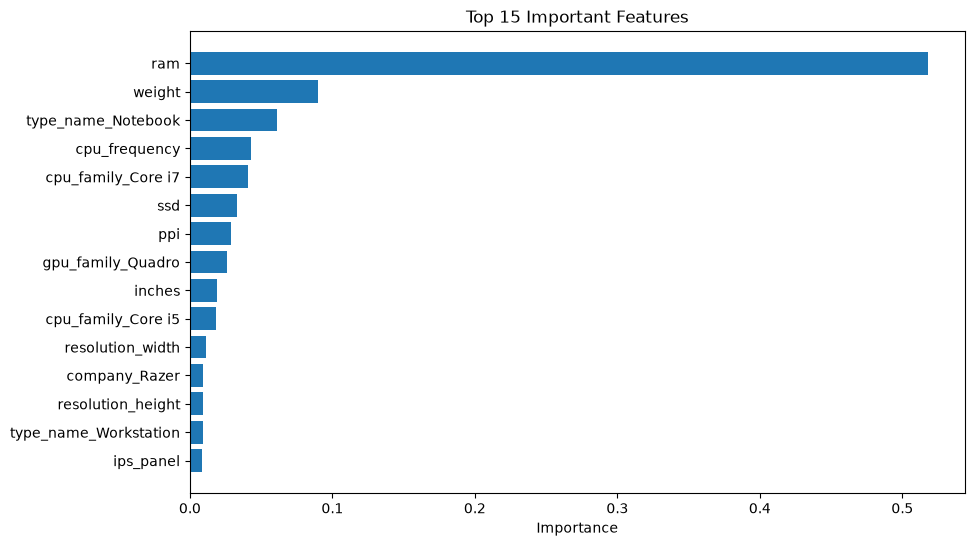

In [22]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15],
)

plt.xlabel("Importance")

plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

# Conclusion

## Random Forest Results

The Random Forest model achieved the best performance among all models.

Performance:

- MAE ≈ 180
- RMSE ≈ 268
- R² ≈ 0.85

---

## Feature Importance

The most important features were:

1. RAM
2. Weight
3. Notebook Type
4. CPU Frequency
5. CPU Family
6. SSD
7. PPI

---

## Final Observation

Random Forest significantly outperformed both Linear Regression and Decision Tree and became the best model so far.